# MediciMess KPI and anomaly-rule example

This executable notebook calls the production ingestion, Phase 3 KPI, and Phase 4 alert functions. Alerts are investigative signals, not proof of misconduct.

In [1]:
from collections import Counter
from datetime import date, timedelta
from decimal import Decimal
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'analytics').is_dir(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from ingestion.pipeline import run_pipeline
from analytics.kpis import calculate_kpis, calculate_expense_details, calculate_loan_details
from analytics.alerts import generate_alerts, detect_duplicate_transactions, detect_structuring

Matplotlib is building the font cache; this may take a moment.


## 1. Ingest through the shared validator

Calling `run_pipeline` preserves the common transaction types (`date`, `Decimal`) and records rejected rows.

In [2]:
ingestion = run_pipeline(PROJECT_ROOT / 'medici_transactions.csv')
assert not ingestion.source_errors, ingestion.source_errors
transactions = ingestion.accepted
pd.Series({'source_rows': ingestion.total_records, 'accepted': ingestion.accepted_count, 'rejected': ingestion.rejected_count, 'duplicates_reported': len(ingestion.duplicate_rows)}, name='count').to_frame()

=== Pipeline Summary ===
Source file:      /Users/hakeem/Projects/MediciMess_Charlie/medici_transactions.csv
Total records:    80230
Accepted:         80230
Rejected:         0
Skipped:          0


,count
source_rows,80230
accepted,80230
rejected,0
duplicates_reported,0


## 2. Calculate monthly KPIs

Each KPI record is one branch/month. Financial values remain `Decimal`; selected presentation values are converted only in a plotting copy.

In [3]:
kpis = calculate_kpis(transactions)
expense_details = calculate_expense_details(transactions)
loan_details = calculate_loan_details(transactions)
assert len({(row['branch'], row['period']) for row in kpis}) == len(kpis)
columns = ['branch', 'period', 'total_cash_inflows', 'total_cash_outflows', 'net_cash_movement', 'total_operating_expenses', 'total_revenue', 'net_income']
kpi_frame = pd.DataFrame([{name: row[name] for name in columns} for row in kpis])
for name in columns[2:]: kpi_frame[name] = kpi_frame[name].map(float)
display(pd.Series({'monthly_kpis': len(kpis), 'expense_details': len(expense_details), 'loan_details': len(loan_details)}, name='records').to_frame())
kpi_frame.head()

,records
monthly_kpis,4897
expense_details,9011
loan_details,14440


,branch,period,total_cash_inflows,total_cash_outflows,net_cash_movement,total_operating_expenses,total_revenue,net_income
0,Florence,1390-01,542443.17,1.471502e+07,-1.417257e+07,2919.60,465851.200000,462931.600000
1,Bruges,1390-01,18887.12,1.818370e+05,-1.629499e+05,7424.59,116.412525,-7308.177475
2,Geneva,1390-01,398918.00,5.353198e+05,-1.364018e+05,2451.45,64850.435520,62398.985520
3,Venice,1390-01,62082.72,2.810771e+05,-2.189944e+05,0.00,68965.290000,68965.290000
4,Rome,1390-01,8620354.63,5.468230e+05,8.073532e+06,0.00,80411.670000,80411.670000


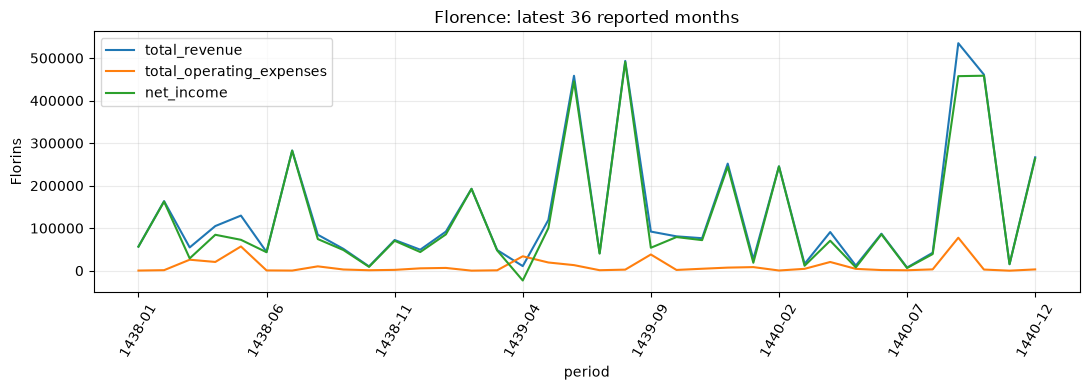

In [4]:
branch_kpis = kpi_frame[kpi_frame['branch'] == 'Florence'].sort_values('period').tail(36)
ax = branch_kpis.plot(x='period', y=['total_revenue', 'total_operating_expenses', 'net_income'], figsize=(11, 4), title='Florence: latest 36 reported months')
ax.set_ylabel('Florins'); ax.grid(alpha=0.25); plt.xticks(rotation=60); plt.tight_layout(); plt.show()

## 3. Run all seven anomaly rules

A: Benford; B: vendor concentration; C: duplicate; D: round-number cluster; E: frequency outlier; F: structuring; G: new high-volume counterparty. Zero is a valid observed count.

In [5]:
alerts = generate_alerts(transactions)
names = {'A':'Benford deviation','B':'Vendor concentration','C':'Possible duplicate','D':'Round-number clustering','E':'Frequency outlier','F':'Structuring','G':'New high-volume counterparty'}
counts = Counter(alert['rule'] for alert in alerts)
display(pd.DataFrame([{'rule': rule, 'detection': name, 'alerts': counts.get(rule, 0)} for rule, name in names.items()]))
assert len({alert['alert_id'] for alert in alerts}) == len(alerts)
pd.DataFrame(alerts)[['alert_id','rule','severity','branch','period','counterparty','description']].head(10)

,rule,detection,alerts
0,A,Benford deviation,308
1,B,Vendor concentration,9011
2,C,Possible duplicate,0
3,D,Round-number clustering,25
4,E,Frequency outlier,1263
5,F,Structuring,0
6,G,New high-volume counterparty,176


,alert_id,rule,severity,branch,period,counterparty,description
0,1,A,MEDIUM,Florence,1390-05,NaN,Benford's Law deviation detected for war_finan...
1,2,A,MEDIUM,Rome,1390-07,NaN,Benford's Law deviation detected for deposit t...
2,3,A,MEDIUM,Florence,1390-10,NaN,Benford's Law deviation detected for war_finan...
3,4,A,MEDIUM,Rome,1390-11,NaN,Benford's Law deviation detected for deposit t...
4,5,A,MEDIUM,Florence,1391-01,NaN,Benford's Law deviation detected for war_finan...
5,6,A,MEDIUM,Florence,1392-05,NaN,Benford's Law deviation detected for war_finan...
6,7,A,MEDIUM,Florence,1392-12,NaN,Benford's Law deviation detected for war_finan...
7,8,A,MEDIUM,Florence,1393-08,NaN,Benford's Law deviation detected for war_finan...
8,9,A,MEDIUM,Florence,1393-12,NaN,Benford's Law deviation detected for war_finan...
9,10,A,MEDIUM,Florence,1394-02,NaN,Benford's Law deviation detected for war_finan...


## 4. Controlled demonstrations for Rules C and F

These fixtures exercise the same production detectors without claiming the examples occurred historically.

In [6]:
def transaction(transaction_id, when, amount, *, counterparty='Example Merchant'):
    return {'id': transaction_id, 'date': when, 'branch': 'Demo', 'type': 'operating_expense', 'counterparty': counterparty, 'description': 'Controlled rule example', 'debit_account': 'Operating Expense', 'debit_amount': Decimal(str(amount)), 'credit_account': 'Cash', 'credit_amount': Decimal(str(amount)), 'credit_account_2': None, 'credit_amount_2': None, 'currency': 'FLR'}
duplicate_fixture = [transaction(900001, date(1500,1,10), '125.00'), transaction(900002, date(1500,1,12), '125.00')]
structuring_fixture = [transaction(901000+i, date(1500,2,1)+timedelta(days=i), '900.00', counterparty='Threshold Example') for i in range(12)]
controlled_alerts = detect_duplicate_transactions(duplicate_fixture) + detect_structuring(structuring_fixture)
assert {alert['rule'] for alert in controlled_alerts} == {'C', 'F'}
pd.DataFrame(controlled_alerts)[['rule','severity','metric_value','threshold_value','affected_transaction_ids','description']]

,rule,severity,metric_value,threshold_value,affected_transaction_ids,description
0,C,MEDIUM,125.00,3,"[900001, 900002]",Possible duplicate operating_expense transacti...
1,F,HIGH,10800.00,10000.00,"[901000, 901001, 901002, 901003, 901004, 90100...",Threshold Example had multiple operating_expen...


## Reproduce

Run `jupyter nbconvert --to notebook --execute --inplace notebooks/kpi_anomaly_rules_demo.ipynb` from the repository root. After contract or rule changes, run pytest and regenerate Phase 5 artifacts.